In [ ]:
# What is Deep Learning? Briefly describe how it evolved and how it differs from traditional machine learning.
'''
Deep Learning is a subset of machine learning that tries to mimic how the human brain processes information.
It uses Artificial Neural Network(ANNs) that have multiple hidden layers which is exactly what it's called deep.
These deep networks can take in raw data, figure out complex patterns, and make decisions largly on their own.

It started with basic mathematical models of biological neurons, but it was heavily limited to sloving only the simplest binary classification problems.
The breakthrough came in with backpropagation technique that finally allowed multi-layer networks to calculate their errors, adjust their own weight and actually learn.
DL finally exploded because the hardware caught up to the math. we have massive training data and powerfull GPUs. which allows us to run and fine-tune massive architectures like LLMs.

In traditional ML Feature Engineering was manual, in DL its automatic
In traditional ML Data Requirements worked perfictly fine on smaller, structured datasets, in DL its need massive amounts of labeled data to actually get highly accurate.
In traditional ML Hardware trained effeciently on standard CPUs, in DL heavily relies on high-performance CPUs to process math.
In traditional ML Interpretability is high, in DL its low
In traditional ML training time is fast to train, in DL its Extremely time-consuming.
'''

In [ ]:
# Explain the basic architecture and functioning of a Perceptron. What are its limitations?
'''
-> The perceptron is the simplest type of artificial neural network.
You can think of it as a single, basic mathematical neuron that takes in multiple inputs, processes them, and spits out a single binary output.

-> Its architecture consists of four main components:
1) Inputs (x): These are the numerical values fed into the model.
2) Weights (w) and Bias (b): Each input is assigned a weight, which represents how "important" that specific input is.
                             The bias is an extra constant added to the mix to shift the activation point, acting sort of like an intercept in a linear equation.
3) Net Input Function (Summation): This is the core mathematical engine. It multiplies every input by its corresponding weight and adds them all together, along with the bias.
4) Activation Function: The raw sum (z) is passed through an activation function to determine the final output.
                        In a classic perceptron, this is usually a Step Function—if the sum is above a certain threshold (like 0), it fires an output of 1; if it is below, it outputs 0.

-> The functioning of a perceptron is a straightforward, feed-forward process:
Step 1: It receives the input data.
Step 2: It calculates the weighted sum of those inputs and adds the bias.
Step 3: It compares that total sum to a threshold using the step function.
Step 4: It makes a decision. If the sum crosses the threshold, the perceptron "fires" (outputs $1$, or "Yes"). If not, it stays dormant (outputs $0$, or "No").
Learning Phase: If the perceptron makes a wrong prediction during training, it automatically slightly adjusts its weights and bias up or down to try and
                get closer to the correct answer next time.

Limitations of the Perceptron
The Linear Separability Problem: This is its biggest flaw. A single-layer perceptron can only learn to divide data with a straight line (a linear hyperplane). Because of this, it cannot solve problems where the data is mixed up in non-linear ways. The most famous example is its inability to solve the XOR (Exclusive OR) logic gate problem.
No Probability Output: Because it relies on a hard step function, its output is strictly black or white (0 or 1). It cannot give you a probability or a "confidence score" (like 0.85 or 85%) like modern networks can.
Single-Layer Constraint: A basic perceptron cannot handle complex feature extraction. If the raw data isn't already well-organized and clearly separated, the perceptron will fail to converge (meaning it will loop endlessly and never figure out the right weights).
'''

In [ ]:
# Describe the purpose of activation function in neural networks. Compare Sigmoid, ReLU, and Tanh functions.
'''
Think of an activation function as the gatekeeper for an artificial neuron.
After a neuron calculates the weighted sum of its inputs (plus the bias), the activation function decides whether that neuron should "fire" and pass its signal on to the next layer.

But its absolute most critical job is introducing non-linearity.
  If we didn't use activation functions, a neural network would just be doing basic linear math.
  No matter how many hundreds of "deep" hidden layers you stacked together, the entire network would mathematically collapse into one single linear equation

Sigmoid:
  - Squeezes any input number into a tiny window between 0 and 1.
  - pros: Great for the final output layer in binary classification tasks (when you just need a straightforward "Yes" or "No" probability).
  - cons: Suffers badly from the vanishing gradient problem. If inputs are too high or too low, the curve flattens out, learning slows to a crawl, and deep networks stop improving.
Tanh:
  - Very similar to Sigmoid, but it is centered at zero, meaning it outputs both negative and positive values.
  - pros: Because it is zero-centered, it usually trains faster and makes the math easier for the network to optimize compared to Sigmoid.
  - cons: Still suffers from the vanishing gradient problem at its extreme edges (when inputs are very large or very small).
ReLU:
  - Incredibly simple: if the input is negative, it outputs zero. If it is positive, it just passes the exact number through unchanged.
  - pros: Computationally very cheap and fast. It also completely solves the "vanishing gradient" problem for positive numbers, which is what allows massive deep models to actually learn efficiently.
  - cons: Suffers from the "Dying ReLU" problem. If a neuron's values drop below zero, it will constantly output zero and effectively "die," never updating or learning anything again.
'''

In [ ]:
# What is the difference between Loss function and Cost function in neural networks? Provide examples.
'''
The simplest way to remember the difference is scale: Loss is micro, and Cost is macro.
  Loss Function: - This calculates the error for a single training example.
                 - It looks at one specific piece of data, compares the model's prediction to the actual truth, and spits out a number representing how badly the model messed
                 up on just that one instance.
  Cost Function: - This calculates the average error across the entire training dataset (or a specific batch).
                 - It aggregates all the individual losses together into one single value. This is the ultimate number the neural network is trying to minimize during training.

Example 1: Regression Tasks (Predicting a Number)
           Imagine you are predicting house prices.
              The Loss Function (Squared Error):            For one specific house, the error is the difference between the true price and predicted price, squared.

              The Cost Function (Mean Squared Error - MSE): To evaluate the model overall, you take the squared errors of all N houses in your dataset, sum them up,
                                                            and divide by N to get the average.

Example 2: Classification Tasks (Categorizing Data)
           Imagine you are training a perceptron to classify images as "Cat" (1) or "Not Cat" (0).
              The Loss Function (Binary Cross-Entropy / Log Loss): For one single image, the function penalizes the model heavily if it confidently predicts the wrong class.

              The Cost Function (Average Cross-Entropy): The cost is simply the average of those individual log losses across every single image you fed into the network during that epoch.

'''

In [ ]:
# What is the role of optimizers in neural networks? Compare Gradient Descent, Adam, and RMSprop.
'''
If the Cost Function is a compass that tells the neural network exactly how wrong its current predictions are, the Optimizer is the steering wheel.
The optimizer’s only job is to minimize that cost function. It does this by figuring out exactly how to adjust the network's internal variables (the weights and biases) after every single pass through the data.
Without an optimizer, a neural network would know it was making mistakes, but it would have absolutely no idea how to fix them.
It calculates the "gradient" (the slope of the error) and takes mathematical steps downhill until it finds the lowest possible error.

Gradient Descent:
  - The baseline method. It calculates the error gradient for the whole dataset and updates all weights by taking a step in the opposite direction using a single, fixed "learning rate."
  - pros: Very easy to understand mathematically. For simple, convex problems (where the error landscape looks like a smooth, perfect bowl), it is guaranteed to find the absolute best solution.
  - cons: It is incredibly slow for massive datasets. It also gets easily trapped in "local minima" (shallow valleys) and stops learning before it finds the true best solution.
Adam:
  - An adaptive method. It changes the learning rate for each individual weight dynamically. It does this by keeping a running average of recent gradient magnitudes, allowing it to take larger steps for flat areas and smaller steps for steep areas.
  - pros: Handles complex, non-convex landscapes (hills and valleys) much better than standard Gradient Descent.
  - cons: Can still occasionally get stuck depending on the specific hyperparameters chosen, and the math is much more computationally heavy than vanilla Gradient Descent.
RMSprop:
  - The modern heavyweight. It combines the best parts of RMSprop (adaptive learning rates) and Momentum (remembering the direction of previous steps so it can build up speed and roll smoothly through valleys).
  - pros: Extremely fast to converge, highly robust, and requires very little manual tuning. It is considered the "best of both worlds."
  - cons: Computationally expensive. In some very specific edge cases (like certain image classification tasks), a perfectly tuned standard Gradient Descent with momentum can technically generalize slightly better.
'''

Starting Training...
Epoch 1/10 | Total Error: 1
Epoch 2/10 | Total Error: 3
Epoch 3/10 | Total Error: 3
Epoch 4/10 | Total Error: 2
Epoch 5/10 | Total Error: 1
Epoch 6/10 | Total Error: 0
Convergence reached! The perceptron has learned the pattern.

Final Weights: [0.2 0.1]
Final Bias: -0.2


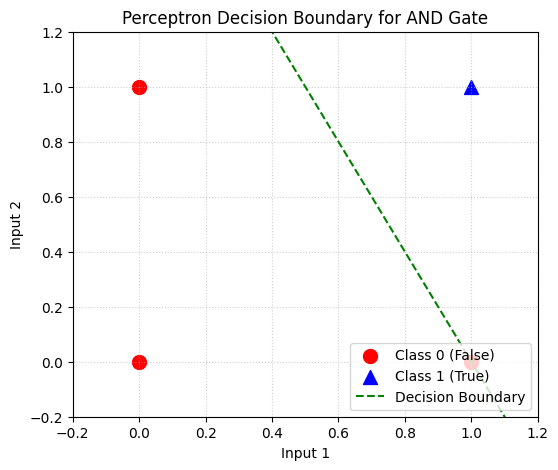

In [1]:
# Write a Python program to implement a single-layer perceptron from scratch using NumPy to solve the logical AND gate.
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Dataset for the AND logic gate
# Inputs: [0,0], [0,1], [1,0], [1,1]
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Outputs: AND gate only outputs 1 when BOTH inputs are 1
y = np.array([0, 0, 0, 1])

# 2. Initialize the Perceptron Parameters
# We need two weights (one for each input feature) and one bias.
# Starting them at zero is standard for a simple perceptron.
weights = np.zeros(X.shape[1])
bias = 0.0

# Hyperparameters
learning_rate = 0.1
epochs = 10  # 10 passes through the data is plenty for an AND gate

print("Starting Training...")

# 3. The Training Loop (Learning Phase)
for epoch in range(epochs):
    total_error = 0

    for i in range(len(X)):
        # Calculate the weighted sum (z = w*x + b)
        z = np.dot(X[i], weights) + bias

        # Apply the Step Activation Function
        # If z > 0, predict 1, else predict 0
        prediction = 1 if z > 0 else 0

        # Calculate the error (Actual - Predicted)
        error = y[i] - prediction
        total_error += abs(error)

        # Update rules: move weights/bias in the direction that fixes the error
        weights += learning_rate * error * X[i]
        bias += learning_rate * error

    print(f"Epoch {epoch + 1}/{epochs} | Total Error: {total_error}")

    # If there are no errors, the perceptron has converged and we can stop early
    if total_error == 0:
        print("Convergence reached! The perceptron has learned the pattern.")
        break

print("\nFinal Weights:", weights)
print("Final Bias:", bias)

# 4. Visualization using Matplotlib
# Plotting the original data points
plt.figure(figsize=(6, 5))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0 (False)', marker='o', s=100)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1 (True)', marker='^', s=100)

# Calculating the Decision Boundary (the line separating the classes)
# The line equation is w1*x1 + w2*x2 + b = 0 -> x2 = -(w1*x1 + b) / w2
x_values = np.array([-0.2, 1.2])
# Add a tiny epsilon to weights[1] to avoid division by zero during early epochs if it plots prematurely
y_values = -(weights[0] * x_values + bias) / (weights[1] + 1e-10)

plt.plot(x_values, y_values, color='green', linestyle='--', label='Decision Boundary')

# Formatting the plot
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.title("Perceptron Decision Boundary for AND Gate")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

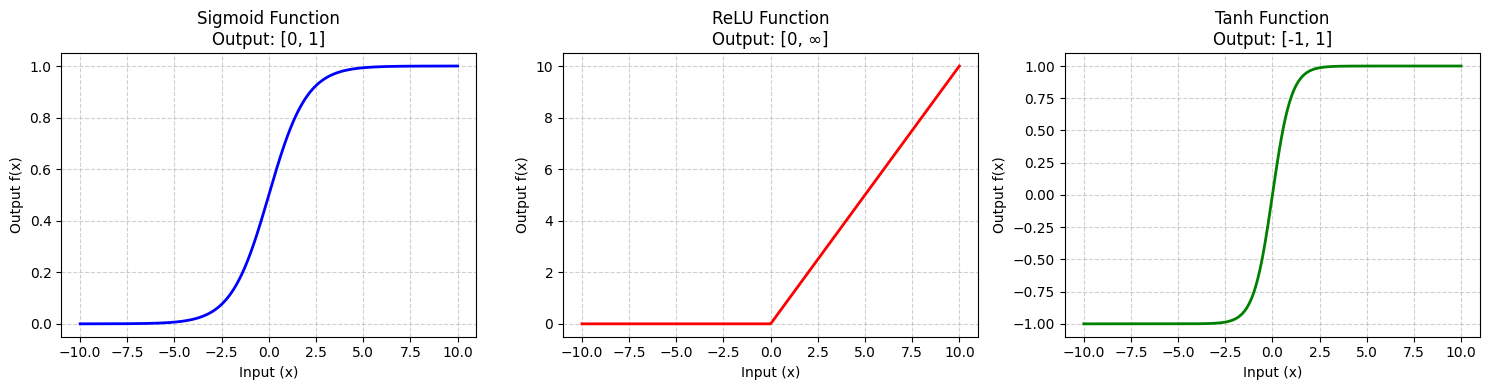

In [2]:
# Implement and visualize Sigmoid, ReLU, and Tanh activation functions using Matplotlib.
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Activation Functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

# 2. Generate Input Data
x = np.linspace(-10, 10, 400)

# 3. Create the Plots
plt.figure(figsize=(15, 4))

# Plot 1: Sigmoid
plt.subplot(1, 3, 1)
plt.plot(x, sigmoid(x), color='blue', linewidth=2)
plt.title("Sigmoid Function\nOutput: [0, 1]")
plt.xlabel("Input (x)")
plt.ylabel("Output f(x)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: ReLU
plt.subplot(1, 3, 2)
plt.plot(x, relu(x), color='red', linewidth=2)
plt.title("ReLU Function\nOutput: [0, ∞]")
plt.xlabel("Input (x)")
plt.ylabel("Output f(x)")
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 3: Tanh
plt.subplot(1, 3, 3)
plt.plot(x, tanh(x), color='green', linewidth=2)
plt.title("Tanh Function\nOutput: [-1, 1]")
plt.xlabel("Input (x)")
plt.ylabel("Output f(x)")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [3]:
# Use Keras to build and train a simple multilayer neural network on the MNIST digits dataset. Print the training accuracy
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

print("Loading and preparing the MNIST dataset...")

# 1. Load the MNIST Dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. Preprocess the Data
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. Build the Neural Network Architecture
model = Sequential([
    # Input Layer: Flattens the 28x28 2D image into a 1D array of 784 pixels
    Flatten(input_shape=(28, 28)),

    # Hidden Layer: 128 neurons using the ReLU activation function
    Dense(128, activation='relu'),

    # Output Layer: 10 neurons (one for each digit 0-9) using Softmax
    Dense(10, activation='softmax')
])

# 4. Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("\nStarting Training Phase...")

# 5. Train the Model
history = model.fit(x_train, y_train, epochs=5)

# 6. Print the Final Training Accuracy
final_accuracy = history.history['accuracy'][-1] * 100

print("-" * 30)
print(f"Training Complete!")
print(f"Final Training Accuracy: {final_accuracy:.2f}%")
print("-" * 30)

Loading and preparing the MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Starting Training Phase...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9285 - loss: 0.2542
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9668 - loss: 0.1126
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9769 - loss: 0.0774
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9827 - loss: 0.0577
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9867 - loss: 0.0441
------------------------------
Training Complete!
Final Training Accuracy: 98.67%
------------------------------


Loading Fashion MNIST data...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Model for 15 epochs...
Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8149 - loss: 0.5213 - val_accuracy: 0.8568 - val_loss: 0.4059
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8606 - loss: 0.3898 - val_accuracy: 0.8667 - val_loss: 0.3705
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8745 - loss: 0.3479 - val_accuracy: 0.8707 - val_loss: 0.3510
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8831 - loss: 0.3186 - val_accuracy: 0.8751 - val_loss: 0.3507
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8902 - loss: 0.3029 - val_accuracy: 0.8735 - val_loss: 0.3567
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8923 - loss: 0.2871 - val_accura

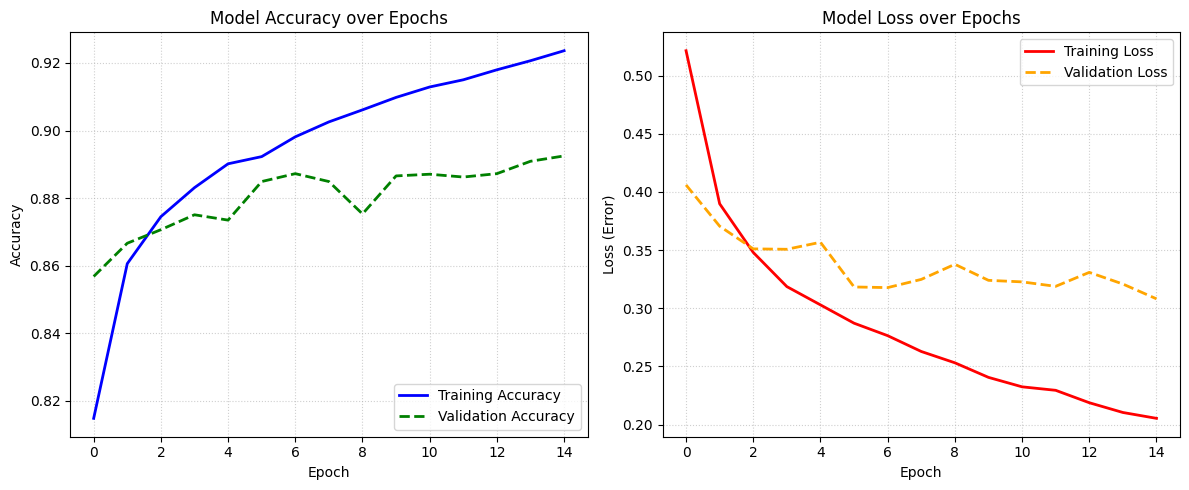

"\nInterpreting the Training Behavior:\n1. The Accuracy Curve (Higher is Better)\n  - Training Accuracy (Blue Line): This shows how well the model is learning the data it is actively studying. It will almost always go steadily up.\n  - Validation Accuracy (Green Dashed Line): This is the more important metric. It shows how well the model is performing on data it has never seen before.\n\n2. The Loss Curve (Lower is Better)\n  - Training Loss (Red Line): This represents the raw error of the model's predictions on the training data. It should curve downward like a slide.\n  - Validation Loss (Orange Dashed Line): This is the error on the unseen validation data.\n"

In [4]:
# Visualize the loss and accuracy curves for a neural network model trained on the Fashion MNIST dataset. Interpret the training behavior
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt

print("Loading Fashion MNIST data...")

# 1. Load Data
fashion_mnist = tf.keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# 2. Preprocess Data (Normalize pixel values to 0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. Build the Model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# 4. Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Training Model for 15 epochs...")

# 5. Train the Model
history = model.fit(x_train, y_train, epochs=15, validation_split=0.2, verbose=1)

# 6. Plotting the Curves
plt.figure(figsize=(12, 5))

# --- Plot 1: Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='green', linestyle='--', linewidth=2)
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

# --- Plot 2: Loss ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='red', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linestyle='--', linewidth=2)
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (Error)')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

'''
Interpreting the Training Behavior:
1. The Accuracy Curve (Higher is Better)
  - Training Accuracy (Blue Line): This shows how well the model is learning the data it is actively studying. It will almost always go steadily up.
  - Validation Accuracy (Green Dashed Line): This is the more important metric. It shows how well the model is performing on data it has never seen before.

2. The Loss Curve (Lower is Better)
  - Training Loss (Red Line): This represents the raw error of the model's predictions on the training data. It should curve downward like a slide.
  - Validation Loss (Orange Dashed Line): This is the error on the unseen validation data.
'''

In [ ]:
# You are working on a project for a bank that wants to automatically detect fraudulent transactions. The dataset is large, imbalanced, and contains structured features like transaction amount, merchant ID, and customer location. The goal is to classify each transaction as fraudulent or legitimate.
# Explain your real-time data science workflow:
# ● How would you design a deep learning model (perceptron or multilayer NN)?
# ● Which activation function and loss function would you use, and why?
# ● How would you train and evaluate the model, considering class imbalance?
# ● Which optimizer would be suitable, and how would you prevent overfitting?


'''
Real-Time Fraud Detection Workflow
1. Model Design: Multilayer Neural Network
  - For a problem of this complexity, a single-layer perceptron would immediately fail because it can only learn linear relationships. Fraud is highly non-linear (e.g., a $5 transaction is completely normal at a coffee shop, but highly suspicious at an electronics store at 3:00 AM).
  - I would design a Multilayer Neural Network (Deep Learning) architecture:

  - Input Layer: Structured data requires specific preprocessing. Numerical features (transaction amount) would be normalized. Categorical features (Merchant ID, customer location) would be converted into vector embeddings so the network can understand relationships between different merchants.
  - Hidden Layers: I would use 2 to 3 hidden layers. We need enough depth to capture complex fraud patterns, but the architecture must remain relatively lightweight. In a real-time banking system, inference (the time it takes the model to make a prediction) must happen in milliseconds so the transaction can be approved or blocked before the card machine times out.

2. Activation and Loss Functions
  - Hidden Layer Activation (ReLU): I would use the ReLU (Rectified Linear Unit) function for the hidden layers. It is computationally cheap—which is critical for real-time inference—and prevents the vanishing gradient problem, allowing the network to train efficiently.
  - Output Layer Activation (Sigmoid): Because this is a strict binary classification problem (1 = Fraud, 0 = Legitimate), the Sigmoid function is required at the output layer. It takes the network's final calculations and squashes them into a clean probability score between 0.0 and 1.0.
  - Loss Function (Binary Cross-Entropy): Also known as Log Loss, this is the standard for binary classification. It heavily penalizes the model for being confidently wrong (e.g., predicting 99% legitimate when the transaction was actually fraudulent).

3. Training and Evaluation (Handling Class Imbalance)
  - In banking, legitimate transactions outnumber fraud by a massive margin (often 99.9% to 0.1%). If not handled, the model will just lazily predict "Legitimate" every single time to achieve 99.9% accuracy.
  - Training Strategy: I would implement Class Weights during training. This modifies the loss function so that making a mistake on a fraudulent transaction penalizes the model 100x more than making a mistake on a normal one. Alternatively, techniques like SMOTE can be used to generate synthetic fraudulent data points to balance the training set.
  - Evaluation Metrics: Standard accuracy is useless here. Instead, I would evaluate the model using:
    - Recall: Out of all actual fraud, how much did the model catch? (High priority for banks to stop financial loss).
    - Precision: When the model flagged a transaction as fraud, how often was it correct? (Important to avoid freezing innocent customers' cards).
    - AUPRC (Area Under the Precision-Recall Curve): The best overall metric for highly imbalanced datasets.

4. Optimizer and Preventing Overfitting
  - Optimizer (Adam): I would use the Adam optimizer. It adapts the learning rate for each parameter individually. This is highly effective when dealing with mixed data types (dense numbers like "amount" mixed with sparse categorical data like "Merchant IDs") and ensures fast, stable convergence.
  - Preventing Overfitting: To ensure the model learns general fraud concepts rather than just memorizing the training data, I would implement:
    - Dropout Layers: Randomly deactivating a percentage of neurons during training so the network doesn't rely too heavily on any single feature (like a specific user's ID).
    - Early Stopping: Monitoring the validation loss and halting the training process the exact moment the model stops improving on unseen data.

-> Production System Deployment: To execute this in real-time, the trained model would be deployed as an event-driven microservice (e.g., running via an AWS Lambda function) integrated tightly with a CI/CD pipeline (like GitLab). This allows the system to instantly process incoming transaction streams and automatically roll out retrained models as new fraud patterns emerge, without causing any banking downtime.
'''